## WEEK 5 - LLM Engineering & Prompting

In [37]:
# Exercise: 3 - Build simple QA bot using LLM API

In [ ]:
from groq import Groq

client = Groq(api_key=)

def chatbot(q):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role":"user","content":q}
        ]
    )
    return response.choices[0].message.content
print("For end the chat just write end or exit")
while True:
    print("="*50)
    q = input("You: ")
    print("="*50)

    if q.lower() == "exit" or  q.lower() == "end":
        print("======== ***Chat ended*** ======.")
        break

    print("Kairos:", chatbot(q))

For end the chat just write end or exit
Kairos: Hello! How's it going?
Kairos: I don't have a personal name. I'm an AI assistant, and you can refer to me as an "assistant" or by my designation, which is not specified.
Kairos: Nice to meet you, I'm Kairos. What would you like to talk about or what task would you like me to assist you with?
Kairos: I'm an artificial intelligence model known as a Large Language Model (LLM). I don't have a personal name, but I'm often referred to as a conversational AI or a chatbot. You can think of me as a helpful assistant that's here to answer your questions and provide information on a wide range of topics. I don't have personal preferences or emotions, but I'm designed to be friendly and assistive. How can I help you today?
Kairos: Mi scias ne la angla ĵezika vortaro "malamikaj" kutima signifas afrontan, kontraŭan, kaj ĝenerale negativan. La vortoj kiel tiuj estas kutime neuzataj kiel la vortoj "amikaj" kiu havas poziĉan valoron.
Kairos: Mikrokaj kuti

In [ ]:
!pip install google-generativeai

In [ ]:
import google.generativeai as genai

genai.configure(api_key="")

model = genai.GenerativeModel("gemini-2.5-flash")

while True:
    print("="*50)
    user_input = input("You: ")
    print("="*50)
    if user_input.lower() == "exit" or user_input.lower() == "end":
        print("======== ***Chat ended*** ======.")
        break

    response = model.generate_content(user_input)
    print("Bot:", response.text)

In [ ]:
for m in genai.list_models():
    print(m.name)

In [24]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score

In [ ]:
df = pd.read_csv("/home/shrutik/smsspam", sep='\t', names=["label", "text"])
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
vect = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    ngram_range=(1,2)
)
X = df['text']
y = df['label']

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [28]:
vect.fit(X_train)
X_train = vect.transform(X_train)
X_test = vect.transform(X_test)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

In [45]:
model = XGBClassifier(n_estimators=300,
                      learning_rate = 0.01,
                      max_depth = 3,
                      eval_metric='logloss', 
                      random_state = 42,
                      subsample=0.8,       
                      colsample_bytree=0.8,
                      reg_alpha=1,     # L1 regularization
                      reg_lambda=1     # L2 Regularization
                      
                      )

In [ ]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)

In [47]:
y_pred = model.predict(X_test)

In [48]:

print(f" {f1_score(y_test, y_pred, average='weighted')} ")


 0.9230481345216928 


In [49]:
print(f"{classification_report(y_test,y_pred)}")


              precision    recall  f1-score   support

           0       0.93      1.00      0.96       966
           1       0.99      0.50      0.67       149

    accuracy                           0.93      1115
   macro avg       0.96      0.75      0.81      1115
weighted avg       0.94      0.93      0.92      1115



In [50]:
results = model.evals_result()

train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

In [ ]:
print(train_loss[0],val_loss[0])   

0.3836558500688842 0.42443320517649563


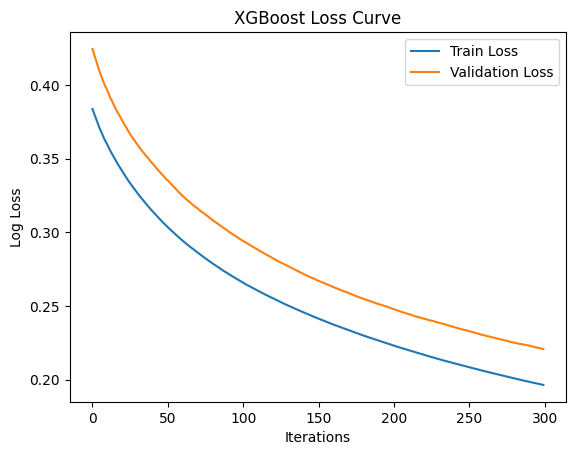

In [52]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('XGBoost Loss Curve')
plt.show()

In [17]:
def check(text):
    text_ne = vect.transform(text)
    result = model.predict(text_ne)
    if result.item() == 0:
        print("Not Spam") 
    else:
        print("Spam")

In [ ]:
check([" Congratulations!!! You win an Iphone"])

Not Spam


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('model', XGBClassifier(eval_metric='logloss'))
])

scores = cross_val_score(pipeline, X, y, cv=7)

print(scores)
print("Mean:", scores.mean())

[0.98115578 0.98115578 0.98492462 0.9798995  0.96482412 0.97487437
 0.97236181]
Mean: 0.9770279971284997


In [ ]:
#  Evaluation metrics in NLP

In [24]:
from nltk.translate.bleu_score import sentence_bleu

# Reference (human translations)
reference = [
    ["the", "cat", "is", "on", "the", "mat"],
    ["there", "is", "a", "cat", "on", "the", "mat"]
]

# Candidate (model output)
candidate = ["the", "cat", "sat", "on", "the", "mat","is"]

# Calculate BLEU
score = sentence_bleu(reference, candidate)

print("BLEU Score:", score)

BLEU Score: 6.608446987146148e-78


In [18]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

reference = "Cats are independent and playful animals"
candidate = "Cats are playful"

scores = scorer.score(reference, candidate)

print("ROUGE-1:", scores['rouge1'])
print("ROUGE-L:", scores['rougeL'])

ROUGE-1: Score(precision=1.0, recall=0.5, fmeasure=0.6666666666666666)
ROUGE-L: Score(precision=1.0, recall=0.5, fmeasure=0.6666666666666666)


In [45]:
import math

# Assume you already computed loss
loss =  0.3855693880463383 # example loss from your model

perplexity = math.exp(loss)

print("Perplexity Score:", perplexity)

Perplexity Score: 1.4704513405402215
